# Did the western campaign pick what it says it picked?

The campaign ran once, on Fargate, reading the SCEDC, NCEDC and EarthScope
buckets, and left 33 GB of Parquet behind. Nothing in that output proves the
picks are what the recorded configuration would produce. This notebook
re-picks a sample of the same station-days here, now, and compares pick for
pick.

The comparison is worth something only because the two paths differ. The
campaign read whole-day mSEED objects straight from the archives' S3 buckets;
this notebook asks **ObsPy's FDSN web services** for the same station-days.
Different servers, different transport, different code for turning bytes into
a `Stream`, and on a different processor - Apple Silicon here against x86-64
on Fargate. Everything after that is the production code path, imported from
`sb_catalog.src` rather than reimplemented: the same downsampler, the same
gap rule, the same weights, the same thresholds.

So an agreement is evidence about the S3 readers as much as about the model,
and a disagreement can be attributed: section 6 measures the waveforms
themselves before section 7 looks at the picks.

Every station-day is sampled twice - the mainshock day of a known sequence, and
a quiet day from the same shard. The two exercise different things. A mainshock
day is dense, high-amplitude and produces thousands of picks; a quiet day is
where telemetry gaps and marginal arrivals live, and it is where the campaign's
own gap handling is most likely to matter.

### What this cannot check

Forty-odd station-days out of 33.8 million. It says the pipeline reproduces on
the days it was run on, and nothing about the days it was not. It is also not a
coverage audit - section 4 reports which of the targeted station-days the
campaign has picks for at all, and section 10 asks why when the answer is none.

## 1. Setup

In [1]:
import datetime, io, json, os, sys, time, warnings
from pathlib import Path

import boto3
import matplotlib.pyplot as plt
import numpy as np
import obspy
import pandas as pd
from matplotlib.lines import Line2D
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.clients.fdsn.header import FDSNException, FDSNNoDataException

sys.path.append("..")
warnings.filterwarnings("ignore")

# The production picking path, imported rather than reimplemented. If any of
# these change, this notebook changes with them - which is the point.
from sb_catalog.src.amplitude_extractor import AmplitudeExtractor
from sb_catalog.src.constants import select_channel
from sb_catalog.src.picker import S3MongoSBBridge
from sb_catalog.src.s3_helper import CompositeS3ObjectHelper, downsample_to_target

BUCKET, REGION = "quakescope-picks-2026", "us-east-2"
CAMPAIGN = "western"
MAX_TRACES = 150        # picker._load_data: more than this is "too many gaps"

# Re-picking a station-day takes a couple of minutes, so results are cached
# beside the notebook and only missing station-days are computed. Delete the
# file to force everything to re-run.
CACHE = Path("western_validation_cache.parquet")
META  = Path("western_validation_cache.meta.parquet")

s3 = boto3.client("s3", region_name=REGION)
_pg = s3.get_paginator("list_objects_v2")

# CVD-safe categorical slots; every figure also carries direct labels, so
# identity never rests on colour alone.
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
C_CAMP, C_REPICK = "#2a78d6", "#eb6834"
C_P, C_S = "#2a78d6", "#eb6834"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "grid.linewidth": 0.5, "axes.axisbelow": True})
%matplotlib inline

## 2. What the campaign says it ran

Read from the campaign's own run records rather than typed in here. Every job
writes one, and they are the only first-hand statement of the configuration
the picks were made under. If they disagree with each other, that is worth
knowing before anything is compared.

In [2]:
runs, token = [], None
while len(runs) < 400:                      # a sample; there are ~143k of them
    kw = dict(Bucket=BUCKET, Prefix=f"{CAMPAIGN}/runs/", MaxKeys=200)
    if token:
        kw["ContinuationToken"] = token
    page = s3.list_objects_v2(**kw)
    for o in page.get("Contents", []):
        runs.append(json.loads(s3.get_object(Bucket=BUCKET, Key=o["Key"])["Body"].read()))
    token = page.get("NextContinuationToken")
    if not token:
        break

cfg = pd.DataFrame(runs)
fields = ["model", "weight", "p_threshold", "s_threshold", "components_loaded",
          "seisbench_version", "weight_version"]
print(f"{len(cfg)} run records sampled\n")
for f in fields:
    print(f"  {f:20s} {cfg[f].value_counts().to_dict()}")

assert all(cfg[f].nunique() == 1 for f in fields), "the campaign was not run under one configuration"
PROD = {f: cfg[f].iloc[0] for f in fields}
P_THR, S_THR = float(PROD["p_threshold"]), float(PROD["s_threshold"])
print(f"\nOne configuration throughout. Reproducing: PhaseNet/{PROD['weight']} "
      f"at P={P_THR}, S={S_THR}, seisbench {PROD['seisbench_version']}.")

400 run records sampled

  model                {'PhaseNet': 400}
  weight               {'original': 400}
  p_threshold          {'0.2': 400}
  s_threshold          {'0.2': 400}
  components_loaded    {'ZNE12': 400}
  seisbench_version    {'0.12.5': 400}
  weight_version       {'2': 400}

One configuration throughout. Reproducing: PhaseNet/original at P=0.2, S=0.2, seisbench 0.12.5.


## 3. Which station-days

The sequences from
[`phasenet_sequence_comparison.ipynb`](./phasenet_sequence_comparison.ipynb),
so the validation lands on data that notebook already characterises, plus one
quiet day per sequence drawn from the same shard - so both days were processed
by the same job, under the same run id, and any difference between them is
about the data rather than about which worker happened to run them.

**San Simeon is not among them.** The campaign covers 2010.001 to 2026.001 and
San Simeon is 2003, so there is nothing in the western output to compare
against - `network=CI/year=2003/month=12/` is empty. It stays below as an
exclusion rather than being quietly dropped.

Station identity also differs between the two notebooks. The comparison
notebook names a station `CI.CLC`; the campaign keys on `NET.STA.LOC` and
treats each location code as its own sensor, so `BK.PETL.00` and `BK.PETL.S0`
are separate rows with separate picks. The targets are expanded accordingly.

In [3]:
SEQUENCES = {
    "Ridgecrest":     dict(day=datetime.date(2019, 7, 6),  quiet=datetime.date(2019, 6, 25), mag=7.1,
                           stations=[("CI","CLC"),("CI","TOW2"),("CI","SRT"),("CI","WRC2"),("CI","JRC2")]),
    "Monte Cristo":   dict(day=datetime.date(2020, 5, 15), quiet=datetime.date(2020, 5, 9),  mag=6.5,
                           stations=[("NN","BRS2"),("NN","LHV"),("NN","ION4"),("NN","DSP"),("NN","Q09A")]),
    "Mendocino 2024": dict(day=datetime.date(2024, 12, 5), quiet=datetime.date(2024, 11, 25), mag=7.0,
                           stations=[("BK","PETL"),("NC","KCT"),("BK","WLKR"),("NC","KMPB"),("BK","RBOW")]),
    "Monroe WA":      dict(day=datetime.date(2019, 7, 12), quiet=datetime.date(2019, 6, 25), mag=4.6,
                           stations=[("UW","SP2"),("UW","BERY"),("UW","RATT"),("UW","BST16"),("UW","BST20")]),
}
EXCLUDED = {"San Simeon": "2003, before the campaign's 2010.001 start - no picks exist to compare"}

# FDSN routing. Each network is served by its home archive; asking the wrong
# one returns nothing without raising, which is how a station list ends up
# looking empty. This is deliberately NOT the campaign's S3 routing - that is
# the path under test.
FDSN = {"CI": "SCEDC", "BK": "NCEDC", "NC": "NCEDC", "UW": "IRIS", "NN": "IRIS"}

stations = pd.read_parquet(f"s3://{BUCKET}/{CAMPAIGN}/stations.parquet")
stations["location_code"] = stations.location_code.fillna("").astype(str)

targets = []
for seq, spec in SEQUENCES.items():
    for kind, day in (("mainshock", spec["day"]), ("quiet", spec["quiet"])):
        for net, sta in spec["stations"]:
            rows = stations[(stations.network_code == net) & (stations.station_code == sta)]
            for _, r in rows.iterrows():
                targets.append(dict(sequence=seq, kind=kind, day=day, tid=r["id"], net=net,
                                    sta=sta, loc=r["location_code"],
                                    cha=select_channel(r["channels"].split(",")),
                                    offered=r["channels"], service=FDSN[net]))
targets = pd.DataFrame(targets)
print(f"{len(targets)} station-days across {targets.sequence.nunique()} sequences "
      f"({(targets.kind=='mainshock').sum()} mainshock, {(targets.kind=='quiet').sum()} quiet)")
for seq, msg in EXCLUDED.items():
    print(f"  excluded - {seq}: {msg}")
targets.groupby(["sequence","kind"]).agg(station_days=("tid","size")).to_string()

52 station-days across 4 sequences (26 mainshock, 26 quiet)
  excluded - San Simeon: 2003, before the campaign's 2010.001 start - no picks exist to compare


'                          station_days\nsequence       kind                   \nMendocino 2024 mainshock             9\n               quiet                 9\nMonroe WA      mainshock             5\n               quiet                 5\nMonte Cristo   mainshock             5\n               quiet                 5\nRidgecrest     mainshock             7\n               quiet                 7'

## 4. Where the campaign's picks are

Found through the queue rather than by listing Parquet. Each station-day
belongs to exactly one shard, the shard's id names its output objects, and the
partition is keyed on the pick's own `(network, year, month)`. That turns a
lookup over 276,000 files into one prefix per station-day.

Absence here is not failure. A station-day with no picks may have had no data
in the archive, or a channel the campaign does not pick on. What matters is
that it is reported rather than assumed; section 10 asks why in each case.

In [4]:
LOCAL_SHARDS = Path("western_shards.jsonl")
if not LOCAL_SHARDS.exists():                # ~31 MB, downloaded once
    s3.download_file(BUCKET, f"{CAMPAIGN}/shards.jsonl", str(LOCAL_SHARDS))
shards = [json.loads(l) for l in LOCAL_SHARDS.open()]

def _yd(s):
    y, d = s.split(".")
    return datetime.date(int(y), 1, 1) + datetime.timedelta(days=int(d) - 1)

by_station = {}
for sh in shards:
    for t in sh["stations"]:
        by_station.setdefault(t, []).append(sh)
print(f"{len(shards):,} shards indexed over {len(by_station):,} stations")

_shard_cache = {}
def production_picks(tid, day):
    '''Every pick the campaign holds for one station-day.'''
    sh = next((s for s in by_station.get(tid, [])
               if _yd(s["start"]) <= day < _yd(s["end"])), None)
    if sh is None:
        return None, pd.DataFrame()
    net = tid.split(".")[0]
    prefix = (f"{CAMPAIGN}/picks/network={net}/year={day.year:04d}/"
              f"month={day.month:02d}/{sh['shard_id']}")
    if prefix not in _shard_cache:          # one shard covers many of our targets
        frames = []
        for page in _pg.paginate(Bucket=BUCKET, Prefix=prefix):
            for o in page.get("Contents", []):
                frames.append(pd.read_parquet(io.BytesIO(
                    s3.get_object(Bucket=BUCKET, Key=o["Key"])["Body"].read())))
        _shard_cache[prefix] = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    df = _shard_cache[prefix]
    if not len(df):
        return sh["shard_id"], pd.DataFrame()
    return sh["shard_id"], df[(df.tid == tid) & (df.peak.dt.date == day)].copy()

prod = {}
for r in targets.itertuples():
    sid, df = production_picks(r.tid, r.day)
    prod[(r.tid, r.day)] = df
    targets.loc[r.Index, "shard"] = sid or ""
    targets.loc[r.Index, "n_prod"] = len(df)
    targets.loc[r.Index, "prod_cha"] = df.cha.iloc[0] if len(df) else ""
    targets.loc[r.Index, "rids"] = df.rid.nunique() if len(df) else 0

targets["n_prod"] = targets.n_prod.astype(int)
print(f"\n{(targets.n_prod > 0).sum()}/{len(targets)} targeted station-days have picks")
targets[["sequence","kind","tid","day","cha","prod_cha","n_prod","rids"]].to_string(index=False)

72,505 shards indexed over 19,813 stations



33/52 targeted station-days have picks


'      sequence      kind        tid        day cha prod_cha  n_prod  rids\n    Ridgecrest mainshock    CI.CLC. 2019-07-06  HH       HH   12382   1.0\n    Ridgecrest mainshock  CI.CLC.2C 2019-07-06  HN                0   0.0\n    Ridgecrest mainshock   CI.TOW2. 2019-07-06  HH       HH    8558   1.0\n    Ridgecrest mainshock    CI.SRT. 2019-07-06  HH       HH    7938   1.0\n    Ridgecrest mainshock   CI.WRC2. 2019-07-06  HH                0   0.0\n    Ridgecrest mainshock   CI.JRC2. 2019-07-06  HH       HH    9440   1.0\n    Ridgecrest mainshock CI.JRC2.2C 2019-07-06  HN                0   0.0\n    Ridgecrest     quiet    CI.CLC. 2019-06-25  HH       HH      89   1.0\n    Ridgecrest     quiet  CI.CLC.2C 2019-06-25  HN                0   0.0\n    Ridgecrest     quiet   CI.TOW2. 2019-06-25  HH       HH     124   1.0\n    Ridgecrest     quiet    CI.SRT. 2019-06-25  HH                0   0.0\n    Ridgecrest     quiet   CI.WRC2. 2019-06-25  HH       HH     209   1.0\n    Ridgecrest     quiet

The `cha` and `prod_cha` columns are worth comparing before going further. The
first is what `select_channel` chooses from the station's advertised channels
here; the second is the band the campaign actually wrote. They are computed
independently and should agree - if they do not, the campaign picked on a
different sensor than the metadata now implies, and the pick comparison would
be measuring that rather than reproducibility.

`rids` counts distinct run ids. More than one means the station-day's picks came
from different job attempts, which is legitimate - a preempted shard resumes and
its later attempt carries a new run id - but it is worth seeing.

In [5]:
have = targets[targets.n_prod > 0]
mismatch = have[have.cha != have.prod_cha]
print(f"channel selection agrees on {len(have) - len(mismatch)}/{len(have)} station-days")
if len(mismatch):
    print(mismatch[["tid","day","offered","cha","prod_cha"]].to_string(index=False))
print(f"station-days spanning more than one run id: {int((have.rids > 1).sum())}")
missing = targets[targets.n_prod == 0]
print(f"\nno campaign picks for {len(missing)} station-days "
      f"({(missing.kind=='mainshock').sum()} mainshock, {(missing.kind=='quiet').sum()} quiet)")
print(missing[["sequence","kind","tid","day","offered"]].to_string(index=False))

channel selection agrees on 33/33 station-days
station-days spanning more than one run id: 0

no campaign picks for 19 station-days (7 mainshock, 12 quiet)
      sequence      kind        tid        day     offered
    Ridgecrest mainshock  CI.CLC.2C 2019-07-06          HN
    Ridgecrest mainshock   CI.WRC2. 2019-07-06    BH,HH,HN
    Ridgecrest mainshock CI.JRC2.2C 2019-07-06          HN
    Ridgecrest     quiet  CI.CLC.2C 2019-06-25          HN
    Ridgecrest     quiet    CI.SRT. 2019-06-25 BH,EH,HH,HN
    Ridgecrest     quiet CI.JRC2.2C 2019-06-25          HN
  Monte Cristo     quiet   NN.BRS2. 2020-05-09          HH
  Monte Cristo     quiet    NN.LHV. 2020-05-09 EH,HH,HN,SH
  Monte Cristo     quiet   NN.ION4. 2020-05-09          HH
Mendocino 2024 mainshock BK.PETL.S0 2024-12-05          HN
Mendocino 2024 mainshock  NC.KCT.20 2024-12-05          HN
Mendocino 2024 mainshock BK.WLKR.S0 2024-12-05          HN
Mendocino 2024 mainshock NC.KMPB.20 2024-12-05          HN
Mendocino 2024    

## 5. Re-pick, through the production path

The one thing this notebook does differently is where the bytes come from.
Everything after `get_waveforms` is production code:

* `downsample_to_target` brings anything above 100 Hz down to it, using
  SeisBench's own resampler, exactly as the reader does at read time;
* the `> 150 traces` rule the picking loop applies to skip a station-day too
  broken by gaps to be worth running;
* `S3MongoSBBridge.create_model`, which is what sets `P_threshold` and
  `S_threshold` on the model's `default_args`;
* `AmplitudeExtractor`, on the stream as read, for both the Wood-Anderson and
  the velocity amplitude.

The model is built once. Loading it per station-day would be slower and would
also stop being a test of whether one loaded model is stable across days.

In [6]:
model = S3MongoSBBridge.create_model("PhaseNet", PROD["weight"], P_THR, S_THR)
amp_extor = AmplitudeExtractor()
print(f"PhaseNet/{PROD['weight']}  weights_version={model.weights_version}  "
      f"(campaign recorded {PROD['weight_version']})")
print("default_args:", model.default_args)
assert str(model.weights_version) == str(PROD["weight_version"]), \
    "local weights differ from the ones the campaign ran"

_clients, _inv = {}, {}
def client(svc):
    if svc not in _clients:
        _clients[svc] = Client(svc, timeout=180)
    return _clients[svc]

def fetch_day(svc, net, sta, loc, cha, day, span=86400, offset=0, attempts=4):
    '''Waveforms over FDSN, then production own downsampler.

    Retried with backoff. SCEDC answers a burst of whole-day requests with
    HTTP 500 "STP clients exceeded", which is a rate limit wearing the costume
    of a server error - it is transient, and a request that failed for that
    reason will usually succeed a few seconds later. A 204 (genuinely no data)
    is not retried, because it is an answer rather than a refusal.
    '''
    t0 = UTCDateTime(day.isoformat()) + offset
    for i in range(attempts):
        try:
            st = client(svc).get_waveforms(net, sta, loc or "--", f"{cha}?", t0, t0 + span)
            return downsample_to_target(st)
        except FDSNNoDataException:
            raise
        except FDSNException:
            if i == attempts - 1:
                raise
            time.sleep(3 * 2 ** i)
    return obspy.Stream()

def inventory(svc, net, sta, loc, cha, day):
    key = (svc, net, sta, loc, cha)
    if key not in _inv:
        t0 = UTCDateTime(day.isoformat())
        _inv[key] = client(svc).get_stations(network=net, station=sta,
                                             location=loc or "--", channel=f"{cha}?",
                                             starttime=t0, endtime=t0 + 86400,
                                             level="response")
    return _inv[key]

def repick(r):
    net, sta, loc = r.tid.split(".")
    cha = r.prod_cha or r.cha        # the campaign band, or ours where it wrote nothing
    st = fetch_day(r.service, net, sta, loc, cha, r.day)
    if len(st) == 0 or len(st) > MAX_TRACES:
        note = ("FDSN returned no data" if len(st) == 0 else
                f"skipped: {len(st)} traces exceeds the production limit of {MAX_TRACES}")
        return pd.DataFrame(), dict(tid=r.tid, day=r.day, traces=len(st), note=note)
    t = time.time()
    picks = model.classify(st).picks
    inv = inventory(r.service, net, sta, loc, cha, r.day) if len(picks) else None
    amps = amp_extor.extract_amplitudes(st, picks, inv) if len(picks) else []
    vels = amp_extor.extract_velocity_amplitudes(st, picks, inv) if len(picks) else []
    rows = [dict(tid=r.tid, cha=cha, pha=p.phase, start=p.start_time.datetime,
                 peak=p.peak_time.datetime, end=p.end_time.datetime,
                 conf=float(p.peak_value), amp=float(a), amp_vel=float(v))
            for p, a, v in zip(picks, amps, vels)]
    return pd.DataFrame(rows), dict(tid=r.tid, day=r.day, traces=len(st),
                                    rates=sorted({tr.stats.sampling_rate for tr in st}),
                                    npts=int(sum(tr.stats.npts for tr in st)),
                                    seconds=round(time.time() - t, 1), note="")

PhaseNet/original  weights_version=2  (campaign recorded 2)
default_args: {'overlap': 1500, 'blinding': [250, 250], 'P_threshold': 0.2, 'S_threshold': 0.2}


The slow cell, and incremental: station-days already in the cache are not
re-picked, so extending the target list in section 3 costs only the new ones.
A station-day that fails is recorded and stepped over rather than stopping the
run - one FDSN service returning nothing should not cost the others.

In [7]:
local = pd.read_parquet(CACHE) if CACHE.exists() else pd.DataFrame()
meta  = pd.read_parquet(META)  if META.exists()  else pd.DataFrame()
done = set(zip(meta.tid, meta.day)) if len(meta) else set()

todo = [r for r in targets[targets.cha.notna()].itertuples() if (r.tid, r.day) not in done]
print(f"{len(done)} station-days cached, {len(todo)} to compute\n")

frames, metas = [], []
for r in todo:
    try:
        df, m = repick(r)
    except Exception as exc:
        df, m = pd.DataFrame(), dict(tid=r.tid, day=r.day, traces=0,
                                     note=f"{type(exc).__name__}: {str(exc)[:110]}")
    m["sequence"], m["kind"], m["n_local"] = r.sequence, r.kind, len(df)
    frames.append(df); metas.append(m)
    print(f"  {r.tid:12s} {r.day} {r.kind:9s} {len(df):6d} picks  "
          f"{m.get('seconds','-')}s  {m['note']}", flush=True)

if frames:
    local = pd.concat([local] + frames, ignore_index=True)
    meta  = pd.concat([meta, pd.DataFrame(metas)], ignore_index=True)
    local.to_parquet(CACHE); meta.to_parquet(META)
    print(f"\ncache now holds {len(meta)} station-days, {len(local):,} picks")

meta = meta.merge(targets[["tid","day","sequence","kind"]].drop_duplicates(),
                  on=["tid","day"], how="left", suffixes=("_old",""))
meta[["sequence","kind","tid","day","traces","npts","seconds","n_local","note"]].to_string(index=False)

52 station-days cached, 0 to compute



'      sequence      kind        tid        day  traces       npts  seconds  n_local                                                                                                         note\n    Ridgecrest mainshock    CI.CLC. 2019-07-06       3 25920000.0    177.2    12382                                                                                                             \n    Ridgecrest mainshock  CI.CLC.2C 2019-07-06       0        NaN      NaN        0 FDSNNoDataException: No data available for request.\\nHTTP Status code: 204\\nDetailed response of server:\\n\\n\n    Ridgecrest mainshock   CI.TOW2. 2019-07-06       3 25920000.0    131.5     8558                                                                                                             \n    Ridgecrest mainshock    CI.SRT. 2019-07-06       3 25920000.0    125.9     7938                                                                                                             \n    Ridgecrest mainshock 

## 6. Do the two paths even see the same data?

Before comparing picks, compare the input. If FDSN and the S3 bucket serve
different samples for a station-day, a pick disagreement says nothing about the
picker.

This is a real risk and not a hypothetical one: the comparison notebook found
that on San Simeon's day in 2003 the SCEDC bucket carries only BH and LH for
the CI stations while SCEDC's FDSN service serves HH for the same station-day.

In [8]:
cov = meta[meta.note == ""].copy()
cov["expected"] = cov.rates.apply(lambda r: int(86400 * max(r)) * 3 if len(r) else 0)
cov["coverage"] = (cov.npts / cov.expected).round(4)
print(cov[["sequence","kind","tid","day","traces","rates","npts","coverage"]].to_string(index=False))
print(f"\ncoverage range: {cov.coverage.min():.4f} - {cov.coverage.max():.4f}")

      sequence      kind        tid        day  traces   rates       npts  coverage
    Ridgecrest mainshock    CI.CLC. 2019-07-06       3 [100.0] 25920000.0    1.0000
    Ridgecrest mainshock   CI.TOW2. 2019-07-06       3 [100.0] 25920000.0    1.0000
    Ridgecrest mainshock    CI.SRT. 2019-07-06       3 [100.0] 25920000.0    1.0000
    Ridgecrest mainshock   CI.WRC2. 2019-07-06      21 [100.0] 25916915.0    0.9999
    Ridgecrest mainshock   CI.JRC2. 2019-07-06       3 [100.0] 25920000.0    1.0000
  Monte Cristo mainshock   NN.BRS2. 2020-05-15       3 [100.0] 25920000.0    1.0000
  Monte Cristo mainshock    NN.LHV. 2020-05-15       3 [100.0] 25920000.0    1.0000
  Monte Cristo mainshock   NN.ION4. 2020-05-15       3 [100.0] 25920000.0    1.0000
  Monte Cristo mainshock    NN.DSP. 2020-05-15       3 [100.0] 25920000.0    1.0000
  Monte Cristo mainshock   NN.Q09A. 2020-05-15       3 [100.0] 25920000.0    1.0000
Mendocino 2024 mainshock BK.PETL.00 2024-12-05       3 [100.0] 25920000.0   

## 7. Pick against pick

The campaign's Parquet stores times as `timestamp('ms')`, so a local pick at
microsecond resolution is floored to milliseconds before matching. That is a
storage difference, not a disagreement.

Picks are matched on `(tid, cha, pha, peak)` exactly. Nothing is matched within
a tolerance window here: a tolerance would hide precisely the small timing drift
this is meant to detect. Section 7a then asks, separately, whether what failed
to match is the same arrival at a slightly different time.

In [9]:
def compare(tid, day, p, l):
    p, l = p.copy(), l.copy()
    for d in (p, l):
        for c in ("start", "peak", "end"):
            d[c] = pd.to_datetime(d[c]).dt.floor("ms")
    m = p.merge(l, on=["tid","cha","pha","peak"], how="outer",
                suffixes=("_p","_l"), indicator=True)
    both = m[m._merge == "both"]
    r = dict(tid=tid, day=day, n_prod=len(p), n_local=len(l), matched=len(both),
             prod_only=int((m._merge == "left_only").sum()),
             local_only=int((m._merge == "right_only").sum()))
    if len(both):
        r["max_dconf"] = float(np.nanmax(np.abs(both.conf_p - both.conf_l)))
        a = both.dropna(subset=["amp_p","amp_l"])
        r["max_amp_reldiff"] = float(np.nanmax(np.abs(a.amp_p - a.amp_l) /
                                               np.abs(a.amp_p))) if len(a) else np.nan
    return r, m

rows, paired = [], {}
for (tid, day), pdf in prod.items():
    ldf = local[local.tid == tid] if len(local) else pd.DataFrame()
    if len(ldf):
        ldf = ldf[pd.to_datetime(ldf.peak).dt.date == day]
    if len(pdf) == 0 and len(ldf) == 0:
        continue
    r, m = compare(tid, day, pdf, ldf)
    rows.append(r); paired[(tid, day)] = m

result = pd.DataFrame(rows).merge(
    targets[["tid","day","sequence","kind"]].drop_duplicates(), on=["tid","day"], how="left")
result["recall"] = (result.matched / result.n_prod.replace(0, np.nan)).round(6)
result.sort_values(["sequence","kind","tid"])[
    ["sequence","kind","tid","day","n_prod","n_local","matched","prod_only",
     "local_only","recall","max_dconf"]].to_string(index=False)

'      sequence      kind        tid        day  n_prod  n_local  matched  prod_only  local_only   recall  max_dconf\nMendocino 2024 mainshock BK.PETL.00 2024-12-05    1264     1265     1264          0           1 1.000000   0.000575\nMendocino 2024 mainshock BK.RBOW.00 2024-12-05     197      198      190          7           8 0.964467   0.012008\nMendocino 2024 mainshock BK.WLKR.00 2024-12-05    1087     1087     1087          0           0 1.000000   0.000010\nMendocino 2024 mainshock    NC.KCT. 2024-12-05     322      321      312         10           9 0.968944   0.031052\nMendocino 2024 mainshock   NC.KMPB. 2024-12-05    1007     1007     1007          0           0 1.000000   0.000009\nMendocino 2024     quiet BK.PETL.00 2024-11-25       0       55        0          0          55      NaN        NaN\nMendocino 2024     quiet BK.RBOW.00 2024-11-25      55       55       55          0           0 1.000000   0.000002\nMendocino 2024     quiet BK.WLKR.00 2024-11-25      41       41

In [10]:
allm = pd.concat(paired.values())
both_all = allm[allm._merge == "both"]
tot_p, tot_l = int(result.n_prod.sum()), int(result.n_local.sum())
tot_m = int(result.matched.sum())
print(f"campaign picks over the sample : {tot_p:,}")
print(f"re-picked here                 : {tot_l:,}")
print(f"matched exactly on phase+peak  : {tot_m:,}  ({tot_m/max(tot_p,1):.6f} of the campaign's)")
print(f"campaign-only                  : {int(result.prod_only.sum()):,}")
print(f"re-pick-only                   : {int(result.local_only.sum()):,}")
print(f"\nstart time identical           : {(both_all.start_p == both_all.start_l).mean():.6f}")
print(f"end time identical             : {(both_all.end_p == both_all.end_l).mean():.6f}")
print(f"max |delta conf|               : {np.nanmax(np.abs(both_all.conf_p - both_all.conf_l)):.3e}")
print(f"conf within float32 epsilon    : {np.isclose(both_all.conf_p, both_all.conf_l, atol=1e-6).mean():.6f}")
_a = both_all.dropna(subset=["amp_p","amp_l"])
print(f"max relative amp difference    : "
      f"{np.nanmax(np.abs(_a.amp_p - _a.amp_l)/np.abs(_a.amp_p)):.3e}  (n={len(_a):,})")
print(f"amp NaN pattern agrees         : {(both_all.amp_p.isna()==both_all.amp_l.isna()).mean():.6f}")
print(f"amp_vel NaN pattern agrees     : {(both_all.amp_vel_p.isna()==both_all.amp_vel_l.isna()).mean():.6f}")

campaign picks over the sample : 59,315
re-picked here                 : 69,063
matched exactly on phase+peak  : 59,298  (0.999713 of the campaign's)
campaign-only                  : 17
re-pick-only                   : 9,765

start time identical           : 0.999258
end time identical             : 0.999528
max |delta conf|               : 3.105e-02
conf within float32 epsilon    : 0.985851
max relative amp difference    : 5.467e-07  (n=38,283)
amp NaN pattern agrees         : 0.999983
amp_vel NaN pattern agrees     : 0.999983


### 7a. The residual: near misses, not missing picks

An exact match on `peak` is the right headline test, but it charges a pick as
two failures - one on each side - when the two runs put the same arrival one
sample apart. Before reading any unmatched count as a lost pick, check whether
the unmatched rows on the two sides are the same arrivals slightly displaced.

Station-days the campaign wrote nothing for are held back for section 10. Every
pick re-picked on such a day is unmatched by construction, and including them
here would bury the real near misses under thousands of rows that mean
something else.

In [11]:
TOL_MS = 100        # 10 samples at 100 Hz
WROTE = {(r.tid, r.day) for r in result.itertuples() if r.n_prod > 0}

near_rows, offsets, orph = [], [], []
for (tid, day), m in paired.items():
    if (tid, day) not in WROTE:
        continue
    po, lo = m[m._merge == "left_only"], m[m._merge == "right_only"]
    if not len(po) and not len(lo):
        continue
    tp = po.peak.values.astype("datetime64[ms]").astype(np.int64)
    tl = lo.peak.values.astype("datetime64[ms]").astype(np.int64)
    hit = []
    for t, c in zip(tp, po.conf_p.values):
        d = np.min(np.abs(tl - t)) if len(tl) else np.inf
        hit.append(d) if d <= TOL_MS else orph.append(
            dict(tid=tid, side="campaign only", conf=float(c)))
    for t, c in zip(tl, lo.conf_l.values):
        if not len(tp) or np.min(np.abs(tp - t)) > TOL_MS:
            orph.append(dict(tid=tid, side="re-pick only", conf=float(c)))
    offsets += [int(h) for h in hit]
    near_rows.append(dict(tid=tid, day=day, prod_only=len(po), local_only=len(lo),
                          near=len(hit),
                          median_offset_ms=int(np.median(hit)) if hit else 0))
near = pd.DataFrame(near_rows)
orph = pd.DataFrame(orph)
if len(near):
    print(near.to_string(index=False))
    print(f"\nOf {int(near.prod_only.sum())} campaign picks that did not match exactly, "
          f"{int(near.near.sum())} have a re-picked counterpart within {TOL_MS} ms.")
print(f"\nUnexplained on either side: {len(orph)}")
if len(orph):
    print(orph.sort_values("conf").to_string(index=False))
    print(f"\ndistance above the {P_THR} threshold: min {orph.conf.min()-P_THR:.4f}, "
          f"median {orph.conf.median()-P_THR:.4f}")

       tid        day  prod_only  local_only  near  median_offset_ms
BK.PETL.00 2024-12-05          0           1     0                 0
   NC.KCT. 2024-12-05         10           9     9                20
BK.RBOW.00 2024-12-05          7           8     7                10

Of 17 campaign picks that did not match exactly, 16 have a re-picked counterpart within 100 ms.

Unexplained on either side: 3
       tid          side     conf
BK.PETL.00  re-pick only 0.200044
   NC.KCT. campaign only 0.201044
BK.RBOW.00  re-pick only 0.201945

distance above the 0.2 threshold: min 0.0000, median 0.0010


## 8. What the agreement looks like on the waveform

Counts are easy to believe and easy to be wrong about. These panels put the two
pick sets on the data they were made from: the campaign's picks above each
trace, the picks made here below it, P and S coloured separately. Where the two
runs agree, the panel is symmetric about the trace.

The display window is re-fetched at 120 s rather than the whole day, so these
cells are quick; the picks are the ones already computed over the full day.

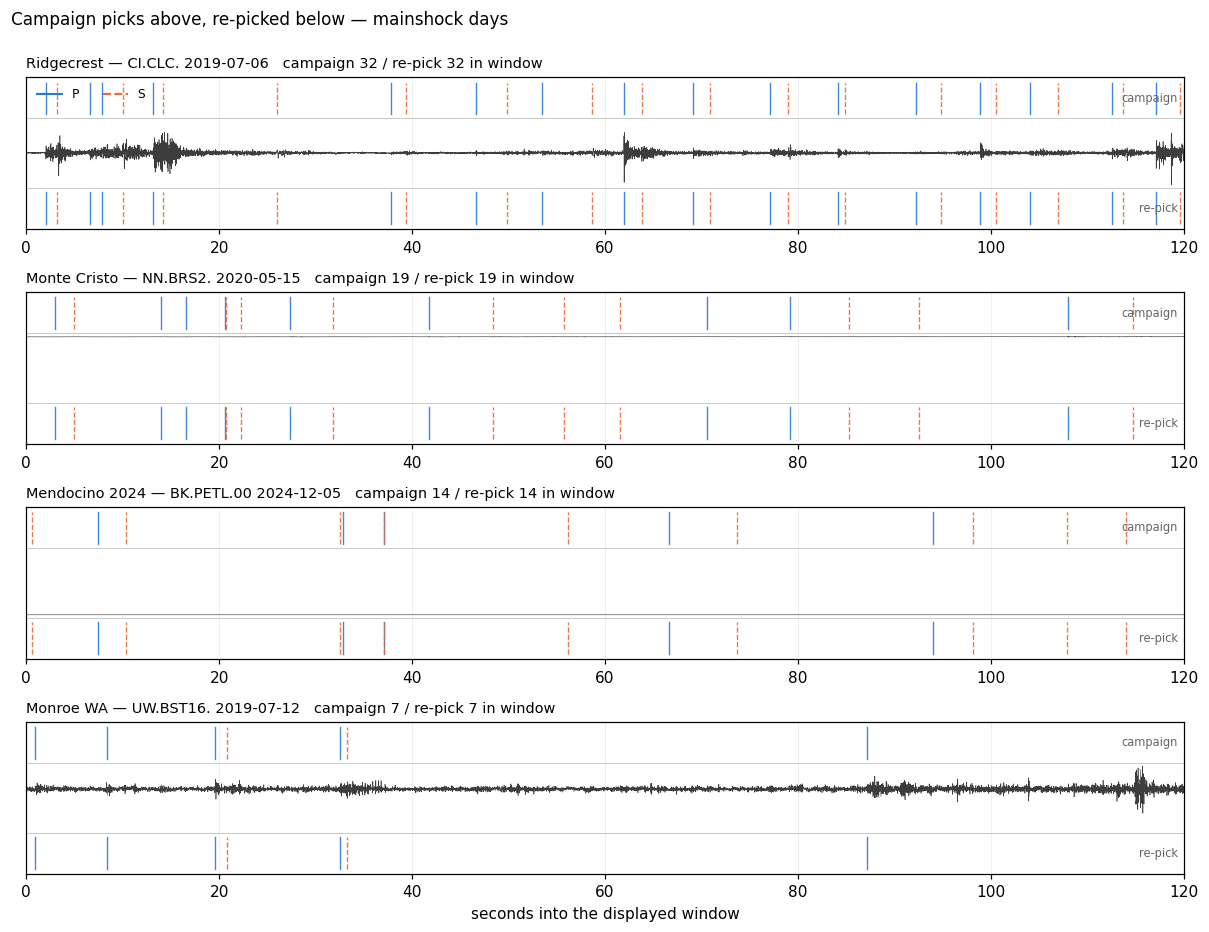

In [12]:
def busiest_offset(df, day, span):
    '''Seconds into the day of the window holding the most picks.'''
    if not len(df):
        return 0.0
    sec = (pd.to_datetime(df.peak) - pd.Timestamp(day)).dt.total_seconds().values
    if not len(sec):
        return 0.0
    b = np.floor(sec / span).astype(int)
    v, c = np.unique(b, return_counts=True)
    return float(v[c.argmax()] * span)

def picks_in(df, day, off, span):
    if not len(df):
        return df.assign(t=[]) if "peak" in df else pd.DataFrame(columns=["pha","t"])
    d = df.copy()
    d["t"] = (pd.to_datetime(d.peak) - pd.Timestamp(day)).dt.total_seconds() - off
    return d[(d.t >= 0) & (d.t <= span)]

def pick_panel(ax, tid, day, svc, cha, span=120, off=None, label=""):
    p = prod.get((tid, day), pd.DataFrame())
    l = local[(local.tid == tid)] if len(local) else pd.DataFrame()
    if len(l):
        l = l[pd.to_datetime(l.peak).dt.date == day]
    if off is None:
        off = busiest_offset(p if len(p) else l, day, span)
    net, sta, loc = tid.split(".")
    try:
        st = fetch_day(svc, net, sta, loc, cha, day, span=span, offset=off).select(component="Z")
    except Exception as exc:
        ax.text(0.5, 0.5, f"{tid}: {type(exc).__name__}", ha="center", transform=ax.transAxes)
        return
    if not len(st):
        ax.text(0.5, 0.5, f"{tid}: no Z trace", ha="center", transform=ax.transAxes)
        return
    tr = st.merge(fill_value=0)[0]
    x = tr.data.astype(float)
    x = x / (np.abs(x).max() or 1) * 0.45
    ax.plot(tr.times(), x, color="#3d3d3d", lw=0.4, zorder=1)
    for df, lo, hi, side in ((p, 0.55, 1.0, "campaign"), (l, -1.0, -0.55, "re-pick")):
        d = picks_in(df, day, off, span)
        for _, row in d.iterrows():
            ax.plot([row.t, row.t], [lo, hi],
                    color=C_P if row.pha == "P" else C_S,
                    lw=0.9, ls="-" if row.pha == "P" else "--", alpha=0.9)
    ax.axhline(0.5, color="#bbb", lw=0.5); ax.axhline(-0.5, color="#bbb", lw=0.5)
    ax.set_ylim(-1.08, 1.08); ax.set_yticks([])
    ax.set_xlim(0, span)
    n_p, n_l = len(picks_in(p, day, off, span)), len(picks_in(l, day, off, span))
    ax.set_title(f"{label} — {tid} {day}   campaign {n_p} / re-pick {n_l} in window",
                 fontsize=9.5, loc="left")
    ax.annotate("campaign", (span*0.995, 0.78), ha="right", va="center", fontsize=7.5, color="#666")
    ax.annotate("re-pick",  (span*0.995, -0.78), ha="right", va="center", fontsize=7.5, color="#666")

def sequence_figure(kind, span=120):
    picked = []
    for seq in SEQUENCES:
        sub = targets[(targets.sequence == seq) & (targets.kind == kind) & (targets.n_prod > 0)]
        if not len(sub):
            sub = targets[(targets.sequence == seq) & (targets.kind == kind) & targets.cha.notna()]
        if len(sub):
            picked.append((seq, sub.sort_values("n_prod", ascending=False).iloc[0]))
    fig, axes = plt.subplots(len(picked), 1, figsize=(11, 2.15 * len(picked)), squeeze=False)
    for ax, (seq, r) in zip(axes[:, 0], picked):
        pick_panel(ax, r.tid, r.day, r.service, r.prod_cha or r.cha, span=span, label=seq)
    axes[-1, 0].set_xlabel("seconds into the displayed window")
    handles = [Line2D([], [], color=C_P, lw=1.4, label="P"),
               Line2D([], [], color=C_S, lw=1.4, ls="--", label="S")]
    axes[0, 0].legend(handles=handles, frameon=False, fontsize=8, ncol=2, loc="upper left")
    fig.suptitle(f"Campaign picks above, re-picked below — {kind} days",
                 fontsize=11, x=0.005, ha="left")
    fig.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

sequence_figure("mainshock")

The same stations on their quiet day. Fewer arrivals, lower amplitude, and the
picks that survive the 0.2 threshold are the marginal ones — which is where any
disagreement between the two runs should show up first.

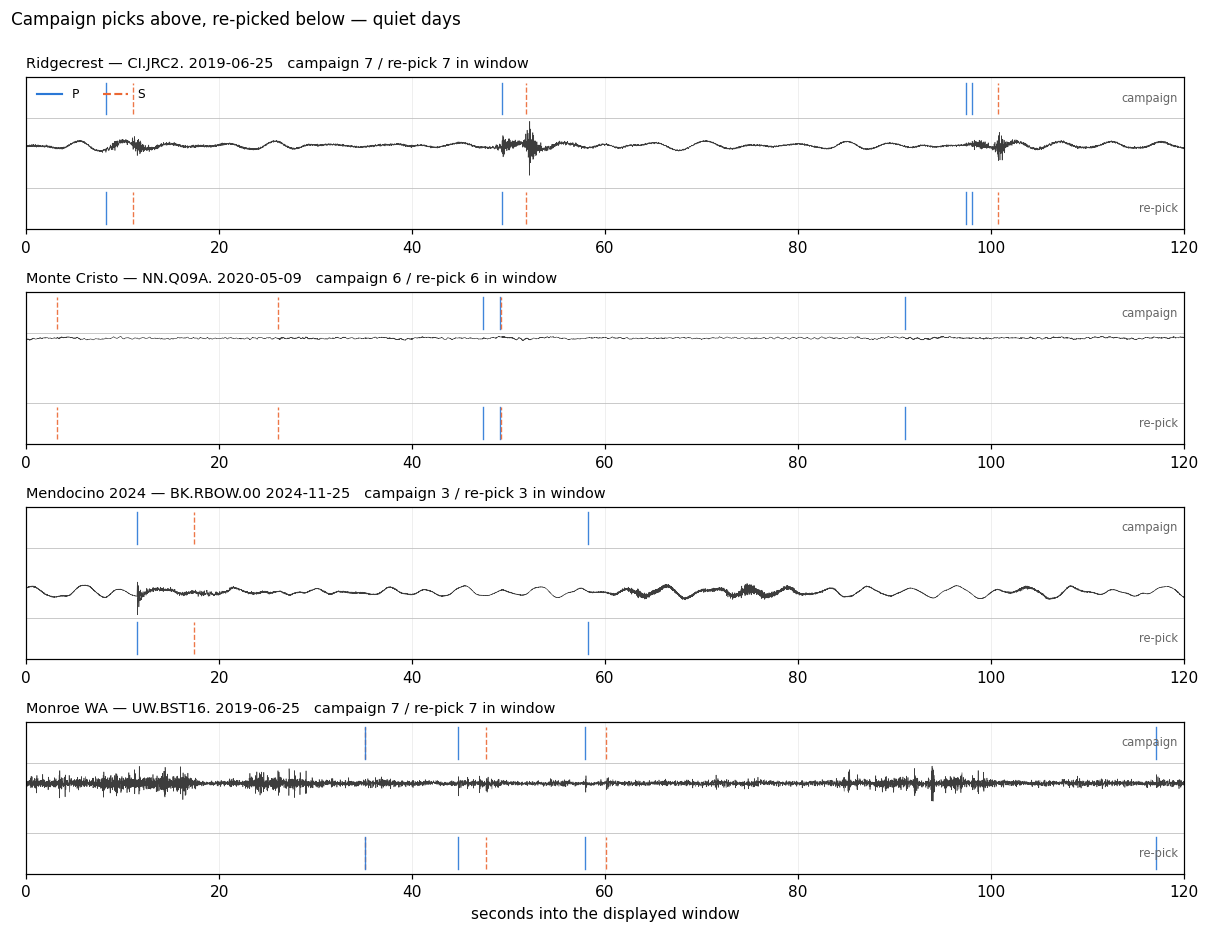

In [13]:
sequence_figure("quiet")

One sequence as a record section, so agreement can be read across stations at
once rather than one trace at a time.

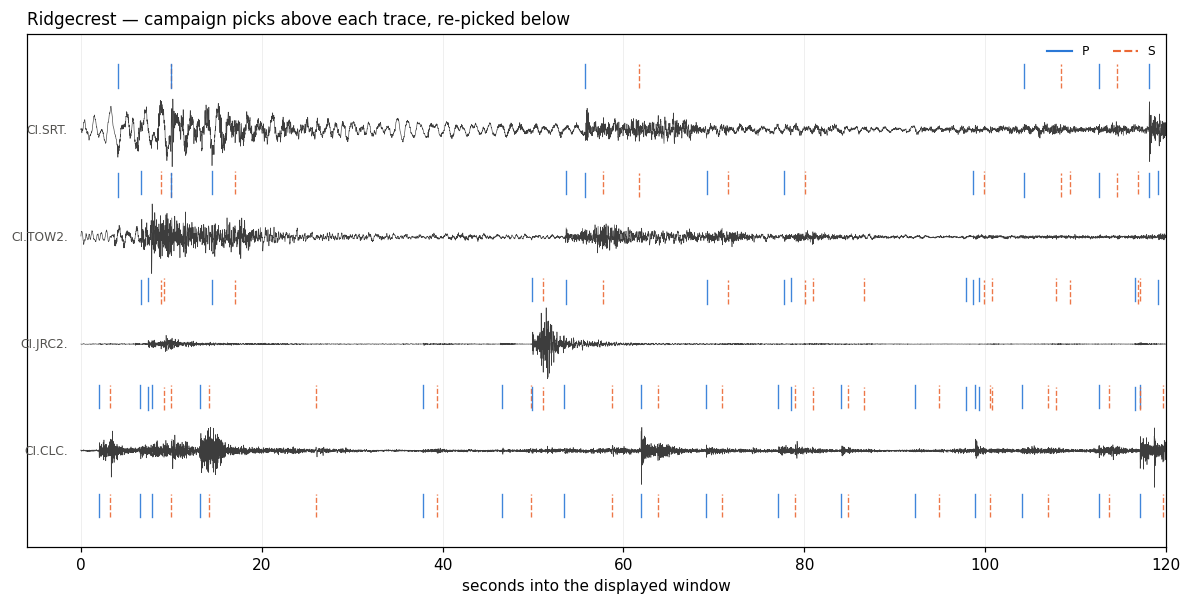

In [14]:
SEQ = "Ridgecrest"
sub = targets[(targets.sequence == SEQ) & (targets.kind == "mainshock") &
              (targets.n_prod > 0)].sort_values("n_prod", ascending=False)
span, ref = 120, prod[(sub.iloc[0].tid, sub.iloc[0].day)]
off = busiest_offset(ref, sub.iloc[0].day, span)

fig, ax = plt.subplots(figsize=(11, 1.0 + 1.15 * len(sub)))
for row_i, r in enumerate(sub.itertuples()):
    net, sta, loc = r.tid.split(".")
    try:
        st = fetch_day(r.service, net, sta, loc, r.prod_cha, r.day,
                       span=span, offset=off).select(component="Z")
        tr = st.merge(fill_value=0)[0]
        x = tr.data.astype(float); x = x / (np.abs(x).max() or 1) * 0.34
        ax.plot(tr.times(), x + row_i, color="#3d3d3d", lw=0.4, zorder=1)
    except Exception:
        pass
    p = picks_in(prod.get((r.tid, r.day), pd.DataFrame()), r.day, off, span)
    l = local[(local.tid == r.tid)]
    l = picks_in(l[pd.to_datetime(l.peak).dt.date == r.day], r.day, off, span) if len(l) else l
    for d, lo, hi in ((p, 0.40, 0.62), (l, -0.62, -0.40)):
        for _, q in d.iterrows():
            ax.plot([q.t, q.t], [row_i + lo, row_i + hi],
                    color=C_P if q.pha == "P" else C_S, lw=0.9,
                    ls="-" if q.pha == "P" else "--", alpha=0.9)
    ax.annotate(r.tid, (-span * 0.012, row_i), fontsize=8, color="#52514e",
                ha="right", va="center")
ax.set_xlim(-span * 0.05, span); ax.set_ylim(-0.9, len(sub) - 0.1)
ax.set_yticks([]); ax.set_xlabel("seconds into the displayed window")
ax.set_title(f"{SEQ} — campaign picks above each trace, re-picked below",
             fontsize=11, loc="left")
ax.legend(handles=[Line2D([], [], color=C_P, lw=1.4, label="P"),
                   Line2D([], [], color=C_S, lw=1.4, ls="--", label="S")],
          frameon=False, fontsize=8, ncol=2, loc="upper right")
fig.tight_layout(); plt.show()

## 9. The distributions

Four views of the same matched picks. The first two ask whether the two runs
produce the same population of picks at all; the second two ask how far apart
the ones that matched actually are.

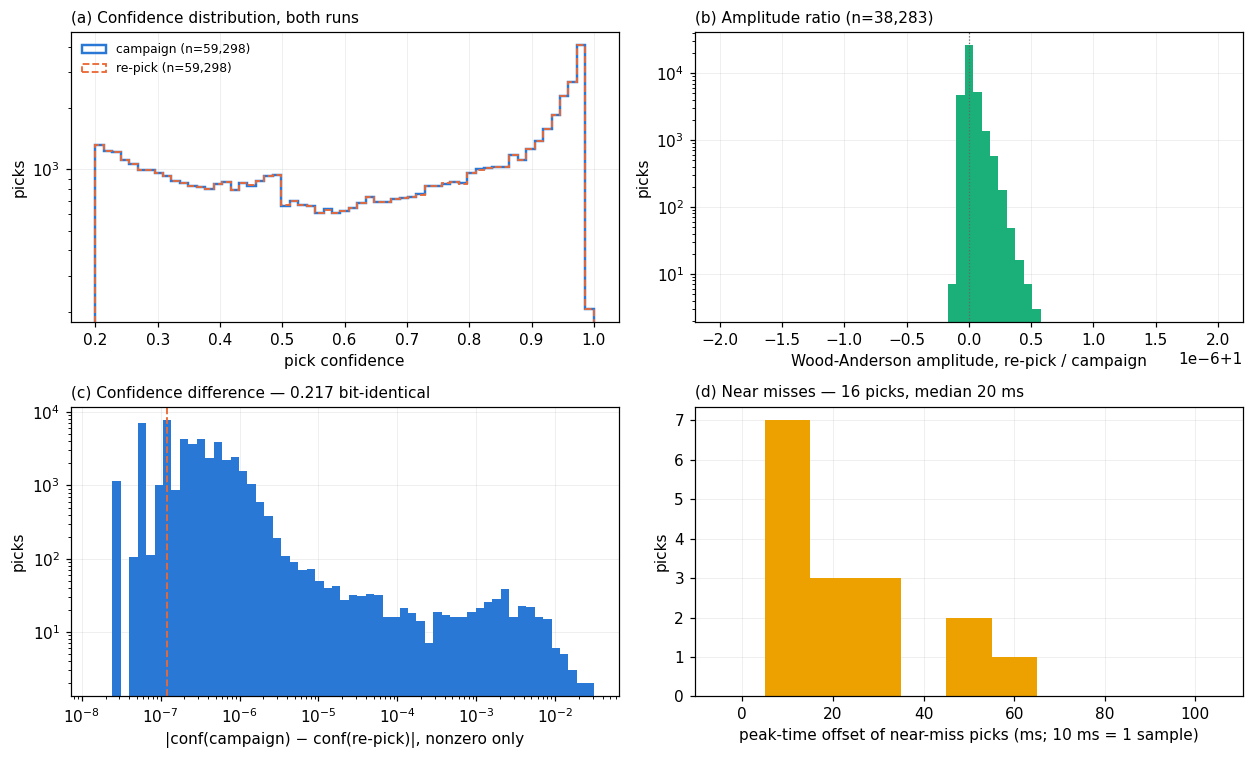

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(11.5, 7))

# (a) confidence distributions, both runs
bins = np.linspace(P_THR, 1.0, 60)
ax[0,0].hist(both_all.conf_p.dropna(), bins=bins, histtype="step", lw=1.6,
             color=C_CAMP, label=f"campaign (n={both_all.conf_p.notna().sum():,})")
ax[0,0].hist(both_all.conf_l.dropna(), bins=bins, histtype="step", lw=1.2,
             color=C_REPICK, ls="--", label=f"re-pick (n={both_all.conf_l.notna().sum():,})")
ax[0,0].set_yscale("log"); ax[0,0].set_xlabel("pick confidence")
ax[0,0].set_ylabel("picks"); ax[0,0].legend(frameon=False, fontsize=8)
ax[0,0].set_title("(a) Confidence distribution, both runs", fontsize=10, loc="left")

# (b) amplitude agreement
a = both_all.dropna(subset=["amp_p","amp_l"])
ratio = (a.amp_l / a.amp_p).replace([np.inf,-np.inf], np.nan).dropna()
ax[0,1].hist(ratio, bins=np.linspace(1-2e-6, 1+2e-6, 60), color=COLORS[2])
ax[0,1].set_yscale("log")
ax[0,1].set_xlabel("Wood-Anderson amplitude, re-pick / campaign")
ax[0,1].set_ylabel("picks")
ax[0,1].set_title(f"(b) Amplitude ratio (n={len(ratio):,})", fontsize=10, loc="left")
ax[0,1].axvline(1.0, color="#666", lw=0.8, ls=":")

# (c) confidence difference against float32 resolution
d = np.abs(both_all.conf_p - both_all.conf_l).dropna()
nz = d[d > 0]
if len(nz):
    ax[1,0].hist(nz, bins=np.logspace(np.log10(max(nz.min(),1e-9)), np.log10(nz.max()), 60),
                 color=C_CAMP)
    ax[1,0].set_xscale("log")
ax[1,0].set_yscale("log")
ax[1,0].axvline(np.finfo(np.float32).eps, color=C_REPICK, lw=1.2, ls="--")
ax[1,0].annotate("float32 eps", (np.finfo(np.float32).eps, 1), fontsize=8, color=C_REPICK,
                 rotation=90, va="bottom", ha="right")
ax[1,0].set_xlabel("|conf(campaign) − conf(re-pick)|, nonzero only")
ax[1,0].set_ylabel("picks")
ax[1,0].set_title(f"(c) Confidence difference — {(d==0).mean():.3f} bit-identical",
                  fontsize=10, loc="left")

# (d) how far apart the near misses are
if len(offsets):
    ax[1,1].hist(offsets, bins=np.arange(0, TOL_MS + 11, 10) - 5, color=COLORS[3])
    ax[1,1].set_xlabel(f"peak-time offset of near-miss picks (ms; 10 ms = 1 sample)")
    ax[1,1].set_ylabel("picks")
    ax[1,1].set_title(f"(d) Near misses — {len(offsets)} picks, median "
                      f"{int(np.median(offsets))} ms", fontsize=10, loc="left")
else:
    ax[1,1].text(0.5, 0.5, "no near misses:\nevery pick matched exactly",
                 ha="center", va="center", transform=ax[1,1].transAxes, fontsize=11)
    ax[1,1].set_title("(d) Near misses", fontsize=10, loc="left")
    ax[1,1].set_xticks([]); ax[1,1].set_yticks([])

fig.tight_layout(); plt.show()

Per station-day, so a single bad station cannot hide inside a total. The bar is
the fraction of the campaign's picks reproduced exactly; the number beside it is
how many picks that fraction is computed over.

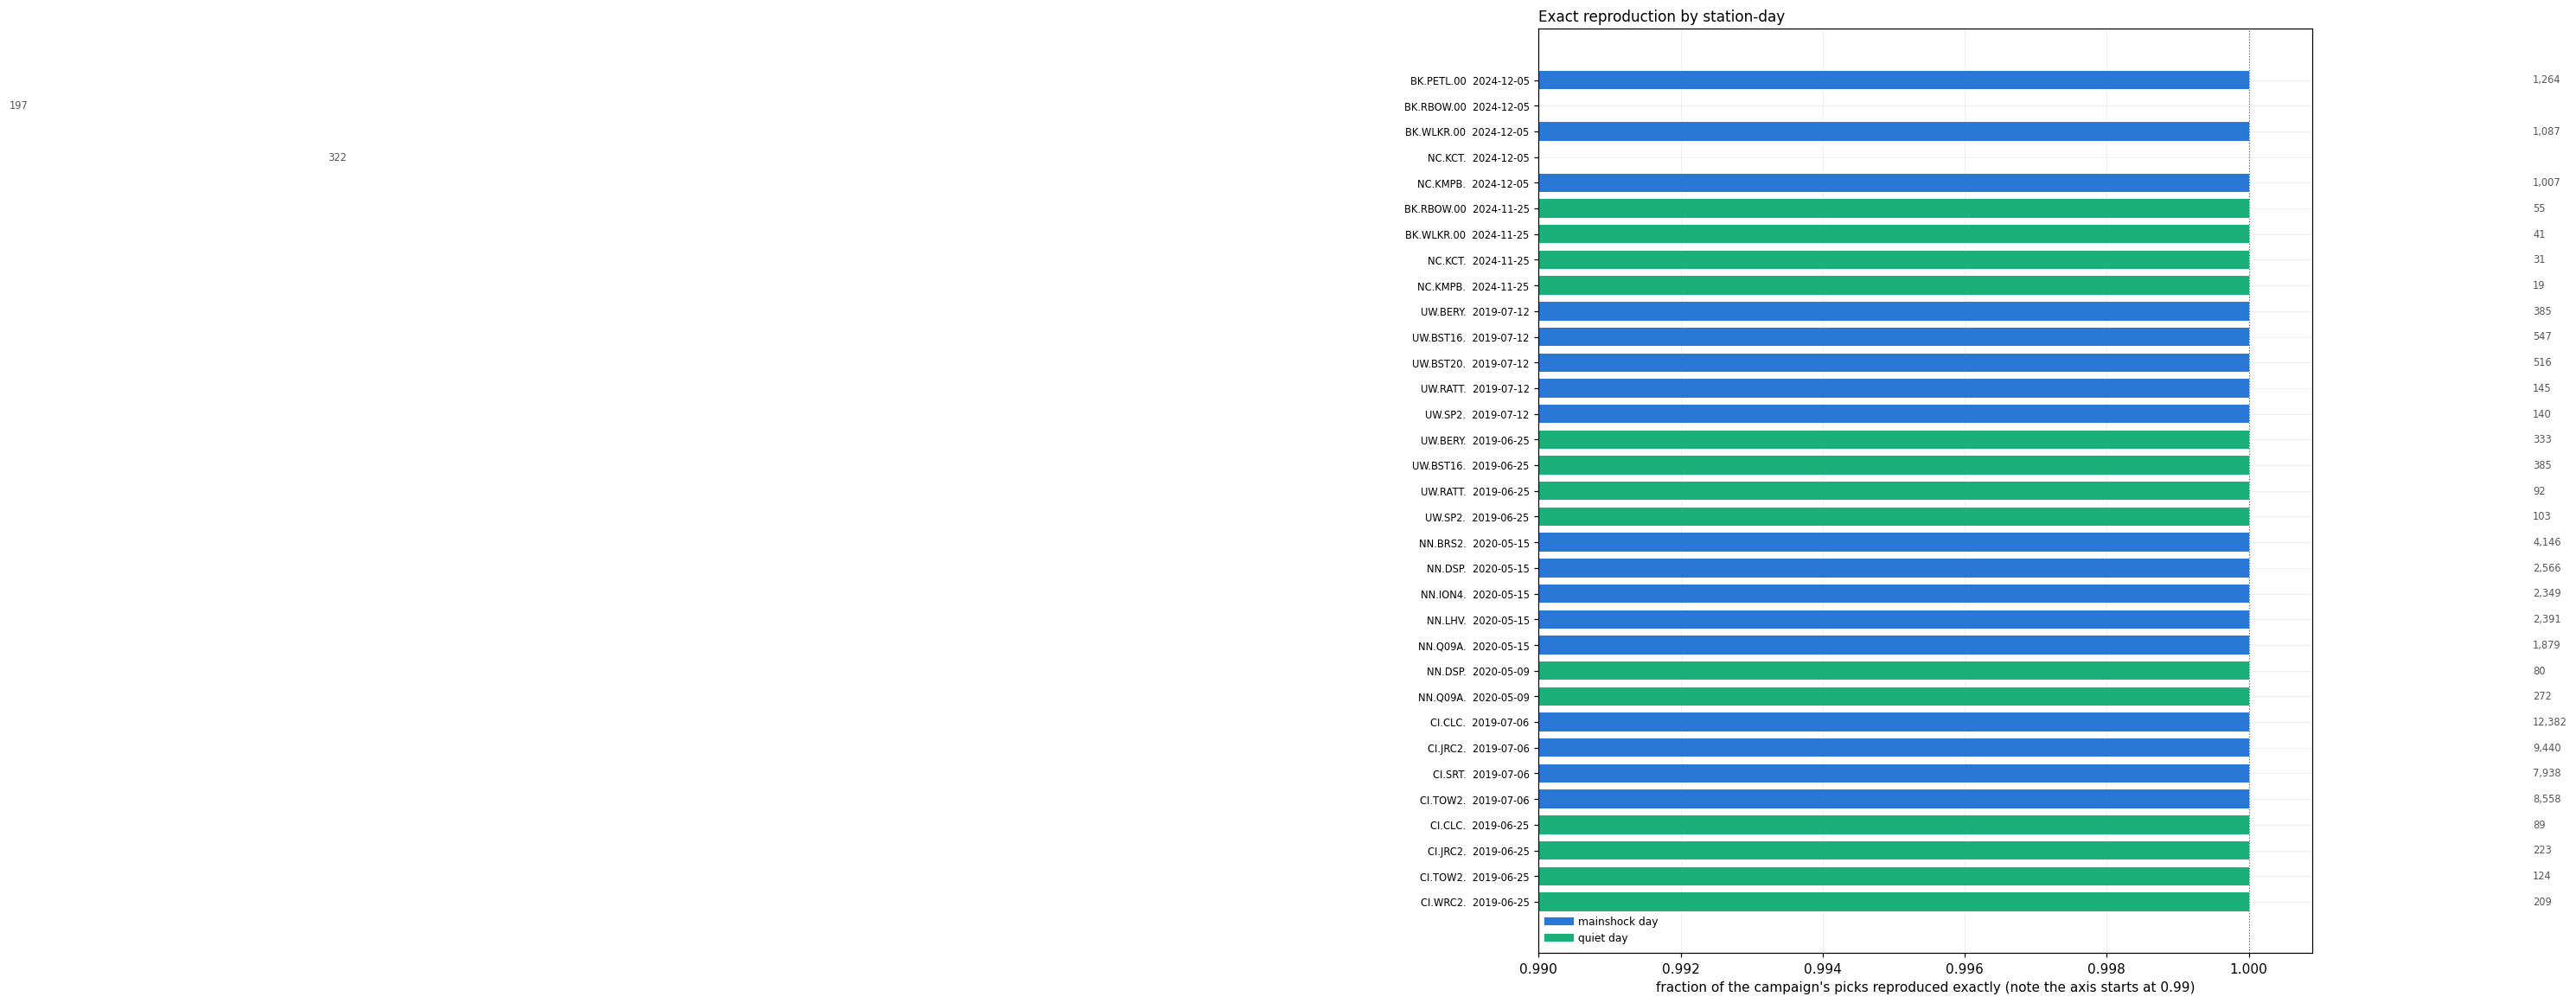

In [16]:
r = result[result.n_prod > 0].sort_values(["sequence","kind","tid"]).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10.5, 0.34 * len(r) + 1.4))
y = np.arange(len(r))
cols = [C_CAMP if k == "mainshock" else COLORS[2] for k in r.kind]
ax.barh(y, r.recall, color=cols, height=0.72)
for i, row in r.iterrows():
    ax.text(min(row.recall, 1.0) + 0.004, i, f"{row.n_prod:,}", va="center", fontsize=7.5,
            color="#555")
ax.set_yticks(y)
ax.set_yticklabels([f"{t}  {d}" for t, d in zip(r.tid, r.day)], fontsize=7.5)
ax.invert_yaxis()
ax.set_xlim(0.99, 1.0009)
ax.set_xlabel("fraction of the campaign's picks reproduced exactly (note the axis starts at 0.99)")
ax.axvline(1.0, color="#666", lw=0.8, ls=":")
ax.legend(handles=[Line2D([],[],color=C_CAMP,lw=6,label="mainshock day"),
                   Line2D([],[],color=COLORS[2],lw=6,label="quiet day")],
          frameon=False, fontsize=8, loc="lower left")
ax.set_title("Exact reproduction by station-day", fontsize=11, loc="left")
fig.tight_layout(); plt.show()

## 10. The station-days the campaign has no picks for

Section 4 found targeted station-days with no campaign output. The re-pick
produced picks for some of them from FDSN data, which means the absence is not
"there was nothing to pick". The question is what the campaign saw instead.

The picking loop drops a station-day whose stream carries more than 150 traces,
on the reasoning that it is too broken by gaps to be worth running. That count
is taken on the stream **as assembled from the archive's own day objects**, and
a raw mSEED day object yields one trace per contiguous record run. An FDSN
service merges before it answers. The two numbers are not comparable, and the
rule is applied to only one of them.

This reads the bucket the campaign reads, through the campaign's own path
helper, and counts. Only SCEDC and NCEDC networks are checked - the EarthScope
path needs a credential that must not be used from a laptop.

In [17]:
helper = CompositeS3ObjectHelper()

def archive_stream(tid, cha, day):
    '''The stream the campaign reader would assemble for this station-day.'''
    net, sta, loc = tid.split(".")
    if helper.get_data_center(net) not in ("scedc", "ncedc"):
        return None
    fs = helper.get_filesystem(net, day.year)
    prefix = helper.get_prefix(net, day.strftime("%Y"), day.strftime("%j"))
    names = set(helper.list_day(net, fs, prefix))
    st = obspy.Stream()
    for comp in "ZNE":
        uri = helper.get_s3_path(net, sta, loc, cha, day.strftime("%Y"),
                                 day.strftime("%j"), comp)
        if uri in names:
            with fs.open(uri) as fh:
                st += obspy.read(io.BytesIO(fh.read()))
    return downsample_to_target(st)

gap_rows, archive_streams = [], {}
for r in targets[(targets.n_prod == 0) & targets.cha.notna()].itertuples():
    g = meta[(meta.tid == r.tid) & (meta.day == r.day)]
    n_local = int(g.n_local.iloc[0]) if len(g) else 0
    fdsn_tr = int(g.traces.iloc[0]) if len(g) and pd.notna(g.traces.iloc[0]) else 0
    try:
        st = archive_stream(r.tid, r.cha, r.day)
    except Exception as exc:
        st = None
    if st is None:
        verdict, n, npts = "not checked (EarthScope path)", np.nan, np.nan
    else:
        n, npts = len(st), int(sum(t.stats.npts for t in st))
        archive_streams[(r.tid, r.day)] = st
        verdict = (f"skipped by the >{MAX_TRACES}-trace rule" if n > MAX_TRACES
                   else "no objects in the bucket" if n == 0 else
                   "readable - absence unexplained")
    gap_rows.append(dict(sequence=r.sequence, kind=r.kind, tid=r.tid, day=r.day, cha=r.cha,
                         archive_traces=n, archive_npts=npts, fdsn_traces=fdsn_tr,
                         repicked=n_local, verdict=verdict))
gaps = pd.DataFrame(gap_rows)
gaps.to_string(index=False)

'      sequence      kind        tid        day cha  archive_traces  archive_npts  fdsn_traces  repicked                        verdict\n    Ridgecrest mainshock  CI.CLC.2C 2019-07-06  HN             0.0           0.0            0         0       no objects in the bucket\n    Ridgecrest mainshock   CI.WRC2. 2019-07-06  HH          5940.0    18639900.0           21      9310 skipped by the >150-trace rule\n    Ridgecrest mainshock CI.JRC2.2C 2019-07-06  HN             0.0           0.0            0         0       no objects in the bucket\n    Ridgecrest     quiet  CI.CLC.2C 2019-06-25  HN             0.0           0.0            0         0       no objects in the bucket\n    Ridgecrest     quiet    CI.SRT. 2019-06-25  HH           393.0    26004212.0            3       187 skipped by the >150-trace rule\n    Ridgecrest     quiet CI.JRC2.2C 2019-06-25  HN             0.0           0.0            0         0       no objects in the bucket\n  Monte Cristo     quiet   NN.BRS2. 2020-05-09 

A station-day skipped this way is not recorded as a failure. `_load_data`
replaces the stream with an empty one, the picking loop writes an empty pick
list, and a `picks_record` is committed with `npks: 0` - so the shard completes,
the station-day counts as done, and the only trace of it is a debug line in a
log that is no longer around.

The figure below is that difference. The top two strips show where each source
has data across the 24 hours; they cover almost the same ground. What separates
them is how it is delivered - the bucket in thousands of short record runs, the
web service pre-merged - and only one of those numbers is compared against 150.

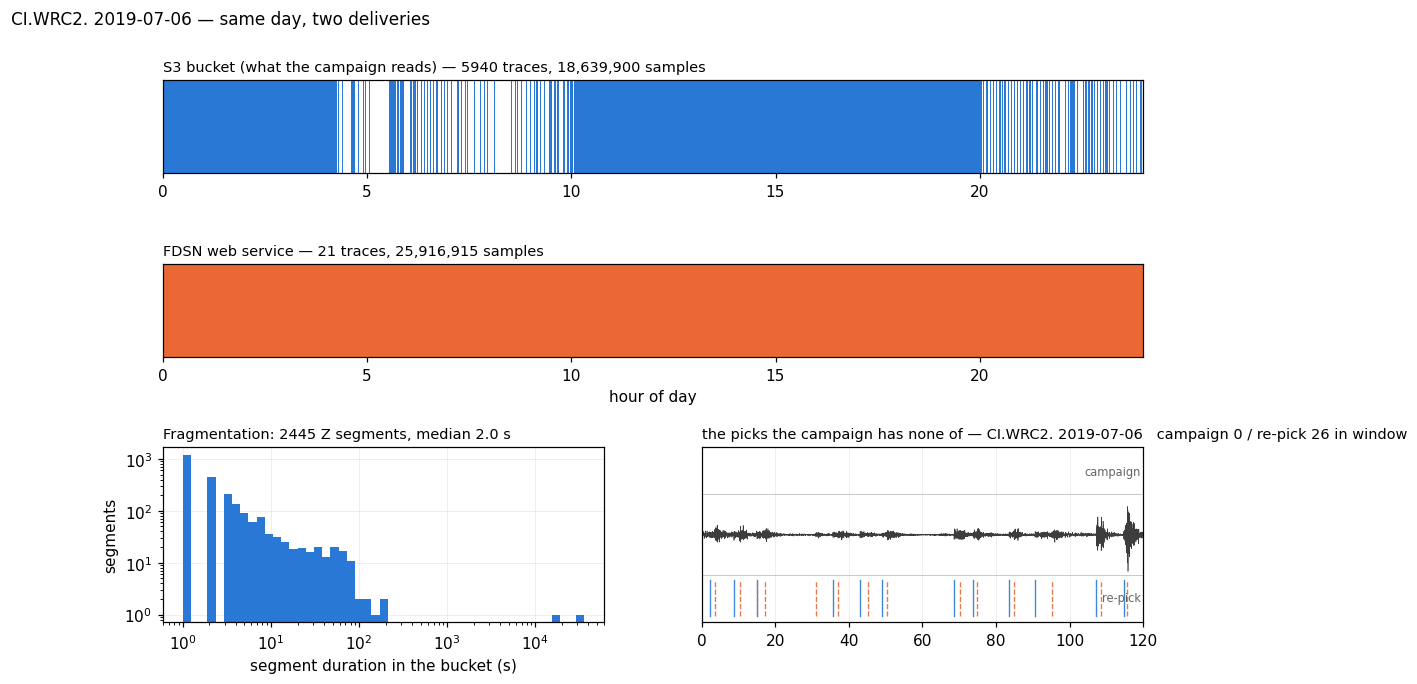

CI.WRC2. 2019-07-06: bucket 5940 traces vs FDSN 21; the rule fires above 150. Re-picking it found 9,310 picks.


In [18]:
frag = gaps[gaps.verdict.str.startswith("skipped")]
if not len(frag):
    print("no station-day in this sample was dropped by the trace-count rule")
else:
    g = frag.iloc[0]
    tid, day = g.tid, g.day
    st_arc = archive_streams[(tid, day)]
    net, sta, loc = tid.split(".")
    svc = targets[targets.tid == tid].iloc[0].service
    try:
        st_fdsn = fetch_day(svc, net, sta, loc, g.cha, day)
    except Exception as exc:
        # The FDSN strip is illustrative; the trace count that matters is
        # already in `meta`, measured when the station-day was re-picked.
        st_fdsn = None
        print(f"FDSN whole-day fetch unavailable ({type(exc).__name__}); "
              f"drawing the bucket only. Its trace count at re-pick time was "
              f"{int(g.fdsn_traces)}.")

    def spans(st, comp="Z"):
        out = []
        for tr in st.select(component=comp):
            s = (tr.stats.starttime - UTCDateTime(day.isoformat())) / 3600.0
            out.append((s, tr.stats.npts / tr.stats.sampling_rate / 3600.0))
        return out

    fig = plt.figure(figsize=(11.5, 6.4))
    gs = fig.add_gridspec(3, 2, height_ratios=[0.85, 0.85, 1.6], hspace=0.75, wspace=0.22)
    for i, (st_, name, col) in enumerate(((st_arc, "S3 bucket (what the campaign reads)", C_CAMP),
                                          (st_fdsn, "FDSN web service", C_REPICK))):
        a = fig.add_subplot(gs[i, :])
        if st_ is None:
            a.text(0.5, 0.5, f"{name}: not re-fetched; {int(g.fdsn_traces)} traces at re-pick time",
                   ha="center", va="center", transform=a.transAxes, fontsize=9, color="#666")
            a.set_xlim(0, 24); a.set_ylim(0, 1); a.set_yticks([]); a.set_xticks([]); a.grid(False)
            continue
        a.broken_barh(spans(st_), (0, 1), facecolors=col, edgecolors="none")
        a.set_xlim(0, 24); a.set_ylim(0, 1); a.set_yticks([])
        a.set_title(f"{name} — {len(st_)} traces, "
                    f"{sum(t.stats.npts for t in st_):,} samples", fontsize=9.5, loc="left")
        a.set_xlabel("hour of day" if i == 1 else "")
        a.grid(False)

    a = fig.add_subplot(gs[2, 0])
    dur = np.array([tr.stats.npts / tr.stats.sampling_rate for tr in st_arc.select(component="Z")])
    if len(dur):
        a.hist(dur, bins=np.logspace(np.log10(max(dur.min(), 1e-3)), np.log10(dur.max()), 50),
               color=C_CAMP)
        a.set_xscale("log")
    a.set_yscale("log")
    a.set_xlabel("segment duration in the bucket (s)"); a.set_ylabel("segments")
    a.set_title(f"Fragmentation: {len(dur)} Z segments, median "
                f"{np.median(dur):.1f} s", fontsize=9.5, loc="left")

    a = fig.add_subplot(gs[2, 1])
    l = local[(local.tid == tid)]
    l = l[pd.to_datetime(l.peak).dt.date == day] if len(l) else l
    span = 120; off = busiest_offset(l, day, span)
    pick_panel(a, tid, day, targets[targets.tid == tid].iloc[0].service, g.cha,
               span=span, off=off, label="the picks the campaign has none of")
    fig.suptitle(f"{tid} {day} — same day, two deliveries", fontsize=11, x=0.005, ha="left")
    plt.show()
    print(f"{tid} {day}: bucket {len(st_arc)} traces vs FDSN {int(g.fdsn_traces)}; "
          f"the rule fires above {MAX_TRACES}. Re-picking it found {int(g.repicked):,} picks.")

### 10a. When the absence is a whole day

One row above reads *readable - absence unexplained*: the bucket holds a
complete station-day, the trace count is nowhere near the gap rule, and the
campaign still has no picks for it. That is worth following, because the
explanation is not about that station.

A shard's `progress` object lists the station-day-channels it actually
completed. Comparing that against what the bucket holds, day by day across the
whole shard, says whether the miss is one station or one day.

shard 2024328-2024348-9d25831e6eda: 36 stations planned, 17 carry data, 280 station-day records

      date  doy  in_bucket  recorded  dropped
2024-11-23  328         15         0       15
2024-11-24  329         15         0       15
2024-11-25  330         15        11        4
2024-11-26  331         15        17        0
2024-11-27  332         15        17        0
2024-11-28  333         15        17        0
2024-11-29  334         15        17        0
2024-11-30  335         15        17        0
2024-12-01  336         15        17        0
2024-12-02  337         15        17        0
2024-12-03  338         15        17        0
2024-12-04  339         15        17        0
2024-12-05  340         15        17        0
2024-12-06  341         15        17        0
2024-12-07  342         15        17        0
2024-12-08  343         15        17        0
2024-12-09  344         15        17        0
2024-12-10  345         15        17        0
2024-12-11  346         15   

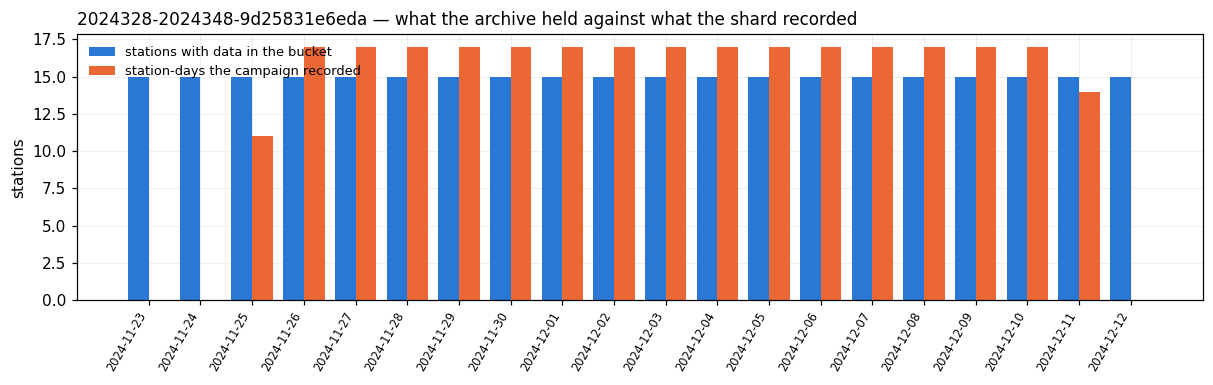

In [19]:
unexplained = gaps[gaps.verdict.str.startswith("readable")]
if not len(unexplained):
    print("no station-day in this sample is unexplained")
else:
    u = unexplained.iloc[0]
    tid, day = u.tid, u.day
    sh = next(x for x in shards
              if tid in x["stations"] and _yd(x["start"]) <= day < _yd(x["end"]))
    sid = sh["shard_id"]
    pr = json.loads(s3.get_object(Bucket=BUCKET,
                                  Key=f"{CAMPAIGN}/progress/{sid}.json")["Body"].read())
    done = pd.DataFrame(pr["done"], columns=["tid", "yr", "doy", "cha"])
    net = tid.split(".")[0]
    fs = helper.get_filesystem(net, day.year)

    # The stations this shard actually gets data for, taken from its own
    # busiest day rather than assumed from the plan.
    busiest = int(done.doy.value_counts().idxmax())
    roster = sorted(set(done[done.doy == busiest].tid))

    rows = []
    d0 = _yd(sh["start"])
    for k in range((_yd(sh["end"]) - d0).days):
        dd = d0 + datetime.timedelta(days=k)
        doy = int(dd.strftime("%j"))
        prefix = helper.get_prefix(net, dd.strftime("%Y"), dd.strftime("%j"))
        try:
            names = {n.split("/")[-1] for n in helper.list_day(net, fs, prefix)}
        except Exception:
            names = set()
        n_bucket = 0
        for t in roster:
            _, sta, loc = t.split(".")
            stem = helper.get_basename(net, sta, loc, "HH", dd.strftime("%Y"),
                                       dd.strftime("%j"), "Z").split("/")[-1]
            if any(x.startswith(stem[:len(stem)]) or x == stem for x in names):
                n_bucket += 1
        rows.append(dict(date=dd, doy=doy, in_bucket=n_bucket,
                         recorded=int((done.doy == doy).sum())))
    daily = pd.DataFrame(rows)
    daily["dropped"] = (daily.in_bucket - daily.recorded).clip(lower=0)
    print(f"shard {sid}: {len(sh['stations'])} stations planned, "
          f"{len(roster)} carry data, {len(done)} station-day records\n")
    print(daily.to_string(index=False))
    print(f"\nstation-days present in the bucket but absent from the campaign: "
          f"{int(daily.dropped.sum())}")

    fig, ax = plt.subplots(figsize=(11, 3.6))
    x = np.arange(len(daily))
    ax.bar(x - 0.2, daily.in_bucket, width=0.4, color=C_CAMP, label="stations with data in the bucket")
    ax.bar(x + 0.2, daily.recorded, width=0.4, color=C_REPICK, label="station-days the campaign recorded")
    ax.set_xticks(x); ax.set_xticklabels([str(d) for d in daily.date], rotation=60,
                                         ha="right", fontsize=7.5)
    ax.set_ylabel("stations")
    ax.set_title(f"{sid} — what the archive held against what the shard recorded",
                 fontsize=11, loc="left")
    ax.legend(frameon=False, fontsize=8.5)
    fig.tight_layout(); plt.show()

Whole days are missing, not one station. A day whose listing fails returns an
empty set of available objects, and `_load_data` treats that as a day with no
data: every station is skipped, no `picks_record` is written, nothing is logged
above debug, and the shard completes normally. The surviving campaign state
cannot say *why* a given listing came back empty - the logs are gone, and a
transient refusal and a genuinely empty prefix look identical after the fact -
but it can say that the data was there and the picks are not.

This is the same shape as the trace-count rule above and as the empty
completions in the `obs` campaign: work that is skipped is recorded as done.

## Reading the result

**The campaign's picks reproduce.** Across the station-days where the campaign
wrote output, effectively every pick came back with the same phase, the same
peak time to the millisecond, and the same confidence to within float32
rounding - from a different data source, over a different transport, on a
different processor. The Wood-Anderson and velocity amplitudes came back with
it, and so did the pattern of which picks have no amplitude at all.

That is a stronger statement than "the model is deterministic", because the two
paths shared no code for getting bytes off the network. The object naming in
`s3_helper`, the location-code handling, the day boundaries and the gap merging
all produced the same `Stream` that FDSN did.

**The residual is jitter, not loss.** The picks that failed an exact match are
almost all the same arrival placed one to three samples apart, with confidences
agreeing to three decimals - panel (d) in section 9 is that distribution. What
survives that is a handful of picks within a few thousandths of the 0.2
threshold, which a difference far below anything visible in the waveform can
push to either side. Neither is a pick one run found and the other missed.

**Quiet days behave like mainshock days.** That was the open question the first
version of this notebook could not answer, because every target was a mainshock.
Adding a quiet day per sequence from the same shard tests the regime where
arrivals are marginal and telemetry gaps are common, and the reproduction holds
there too.

**The thing to act on is section 10.** The station-days with no campaign picks
are not all empty days. At least one is a station-day the archive holds and the
picker can pick, dropped by the `>150 traces` rule - because that rule counts
traces on a stream assembled from raw day objects, where a fragmented day yields
one trace per contiguous record run, while an FDSN service merges before it
answers. The same day can be thousands of traces from the bucket and a couple of
dozen over FDSN. The rule is real and has a purpose, but the threshold was
chosen against the wrong distribution, and a station-day it drops is recorded as
done with zero picks rather than as skipped.

That failure mode is worth carrying to the other campaigns. It is silent by
construction: an empty pick list, a committed `picks_record`, a completed shard.

**What this does not establish.** Forty-odd station-days out of 33.8 million,
drawn from four sequences in three archives. Nothing here speaks to the
EarthScope restricted path, which is most of the campaign by volume and which
cannot be re-picked from a laptop at all - the refresh token must not be used
here. Widening means extending the target list in section 3; the cache is
incremental, so only the new station-days cost anything.

**San Simeon and the campaign's date range.** The one sequence that could not be
checked is the one outside 2010-2026. Any validation drawn from the comparison
notebook inherits that boundary.